## 1.1 Importaciones y Configuración

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, WeightedRandomSampler
from torchvision import datasets, transforms, models
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score
import seaborn as sns
from collections import Counter
import copy, time, warnings
warnings.filterwarnings('ignore')

# Configuración global
CONFIG = {
    'data_path': 'Datos/images/MULTICLASE',
    'batch_size': 32,
    'img_size': 224,
    'seed': 42
}

# ============================================
# CONFIGURACIÓN GPU (CUDA) - OBLIGATORIO
# ============================================
if not torch.cuda.is_available():
    raise RuntimeError("ERROR: CUDA no disponible. Este notebook requiere GPU.")

DEVICE = torch.device('cuda')
torch.cuda.set_device(0)

# Reproducibilidad en GPU
torch.manual_seed(CONFIG['seed'])
np.random.seed(CONFIG['seed'])
torch.cuda.manual_seed(CONFIG['seed'])
torch.cuda.manual_seed_all(CONFIG['seed'])
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = True

# Limpiar caché GPU
torch.cuda.empty_cache()

# Info GPU
print("="*60)
print("GPU CONFIGURADA CORRECTAMENTE")
print("="*60)
print(f"Device: {DEVICE}")
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"Memoria Total: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
print(f"CUDA Version: {torch.version.cuda}")
print(f"PyTorch Version: {torch.__version__}")
print("="*60)



GPU CONFIGURADA CORRECTAMENTE
Device: cuda
GPU: NVIDIA GeForce RTX 4070 Laptop GPU
Memoria Total: 8.59 GB
CUDA Version: 12.8
PyTorch Version: 2.9.1+cu128


In [5]:
# Cargar dataset
full_dataset = datasets.ImageFolder(root=CONFIG['data_path'])
class_names = full_dataset.classes
num_classes = len(class_names)
class_counts = Counter(full_dataset.targets)

print(f"{'='*50}")
print(f"DATASET: {len(full_dataset)} imágenes | {num_classes} clases")
print(f"{'='*50}\n")

for idx, name in enumerate(class_names):
    count = class_counts[idx]
    pct = 100 * count / len(full_dataset)
    bar = "█" * int(count / 5)
    marker = " ← MINORITARIA" if name == 'MEL' else ""
    print(f"{name}: {count:3d} ({pct:5.1f}%) {bar}{marker}")

print(f"\nRatio desbalance: {max(class_counts.values())/min(class_counts.values()):.1f}x")

DATASET: 802 imágenes | 6 clases

ACK: 150 ( 18.7%) ██████████████████████████████
BCC: 150 ( 18.7%) ██████████████████████████████
MEL:  52 (  6.5%) ██████████ ← MINORITARIA
NEV: 150 ( 18.7%) ██████████████████████████████
SCC: 150 ( 18.7%) ██████████████████████████████
SEK: 150 ( 18.7%) ██████████████████████████████

Ratio desbalance: 2.9x


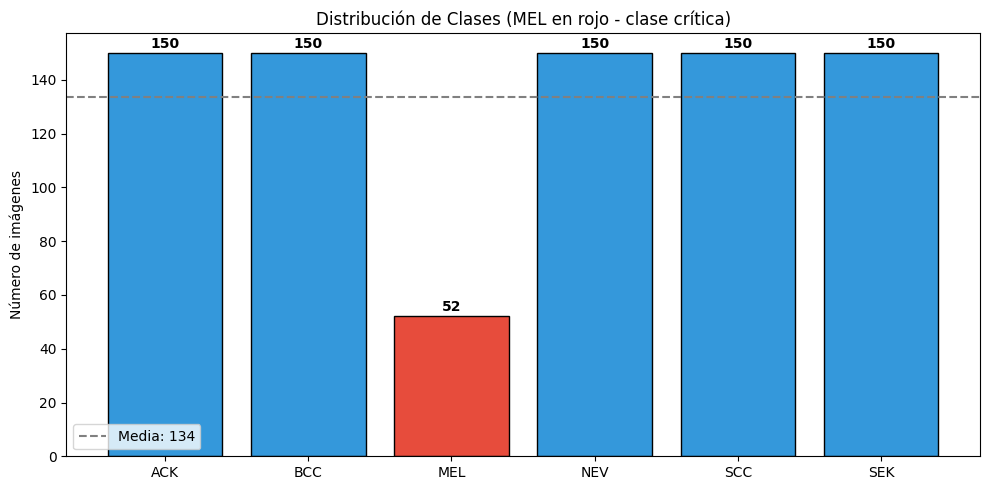

In [6]:
# Visualización
fig, ax = plt.subplots(figsize=(10, 5))
counts = [class_counts[i] for i in range(num_classes)]
colors = ['#e74c3c' if n == 'MEL' else '#3498db' for n in class_names]
bars = ax.bar(class_names, counts, color=colors, edgecolor='black')
for bar, c in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, str(c), ha='center', fontweight='bold')
ax.axhline(np.mean(counts), color='gray', linestyle='--', label=f'Media: {np.mean(counts):.0f}')
ax.set_title('Distribución de Clases (MEL en rojo - clase crítica)')
ax.set_ylabel('Número de imágenes'); ax.legend()
plt.tight_layout(); plt.show()

In [ ]:
## 1.4 División Estratificada y Data Augmentation



In [7]:
# División estratificada 70/15/15
targets = full_dataset.targets
indices = list(range(len(full_dataset)))

train_idx, temp_idx = train_test_split(indices, test_size=0.3, stratify=targets, random_state=CONFIG['seed'])
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, stratify=[targets[i] for i in temp_idx], random_state=CONFIG['seed'])

print(f"Train: {len(train_idx)} | Val: {len(val_idx)} | Test: {len(test_idx)}")

Train: 561 | Val: 120 | Test: 121
